<a href="https://colab.research.google.com/github/MGB12O2/mBneuroAI/blob/main/PINN_model_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install torch if needed
!pip install torch matplotlib numpy

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

Define Device Physics Model

This represents the photocurrent–binding energy relation used in your paper.

𝐼
𝑝
ℎ
(
𝐸
𝑏
)
=
𝐼
0
𝑒
−
(
𝐸
𝑏
−
𝐸
𝑜
𝑝
𝑡
)
2
/
2
𝜎
2
I
ph
	​

(E
b
	​

)=I
0
	​

e
−(E
b
	​

−E
opt
	​

)
2
/2σ
2

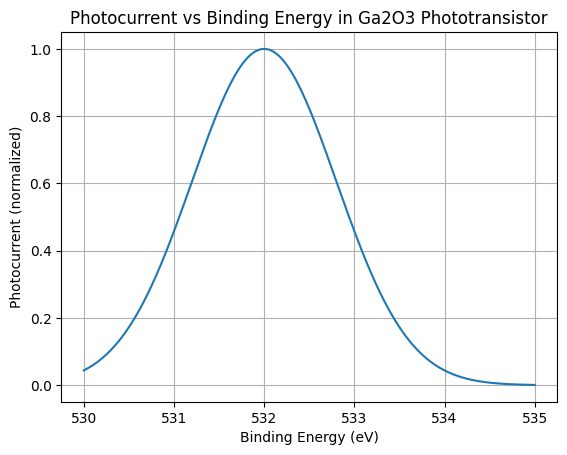

In [ ]:
# Device parameters

I0 = 1.0
Eopt = 532
sigma = 0.8

Eb = np.linspace(530,535,200)

I_ph = I0*np.exp(-(Eb-Eopt)**2/(2*sigma**2))

plt.figure()
plt.plot(Eb,I_ph)
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Photocurrent (normalized)")
plt.title("Photocurrent vs Binding Energy in Ga2O3 Phototransistor")
plt.grid(True)
plt.show()

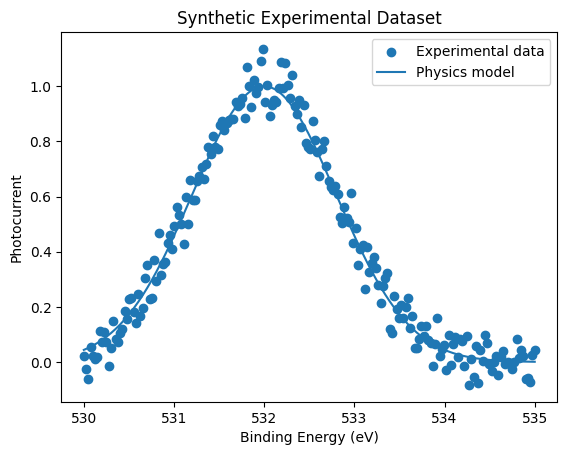

In [ ]:
#Generate Synthetic Experimental Data

#Add noise to simulate real device measurements.

noise = 0.05*np.random.randn(len(I_ph))
I_exp = I_ph + noise

plt.figure()
plt.scatter(Eb,I_exp,label="Experimental data")
plt.plot(Eb,I_ph,label="Physics model")
plt.legend()
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Photocurrent")
plt.title("Synthetic Experimental Dataset")
plt.show()

In [ ]:
Eb_t = torch.tensor(Eb,dtype=torch.float32).view(-1,1)
I_exp_t = torch.tensor(I_exp,dtype=torch.float32).view(-1,1)

In [ ]:
#5. Define the Physics-Informed Neural Network

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,1)
        )

    def forward(self,x):
        return self.net(x)

model = PINN()

In [ ]:
#6. Define the Physics Loss Function
def physics_model(Eb):

    return I0*torch.exp(-(Eb-Eopt)**2/(2*sigma**2))

In [ ]:
#7. Train the PINN

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

loss_history=[]

for epoch in range(5000):

    pred = model(Eb_t)

    data_loss = torch.mean((pred-I_exp_t)**2)

    physics_target = physics_model(Eb_t)

    physics_loss = torch.mean((pred-physics_target)**2)

    loss = data_loss + physics_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch%500==0:
        print(epoch,loss.item())

0 1.3368890285491943
500 0.25572556257247925
1000 0.25572556257247925
1500 0.25572556257247925
2000 0.25572556257247925
2500 0.2557255029678345
3000 0.25572556257247925
3500 0.25572556257247925
4000 0.25572556257247925
4500 0.2559802532196045


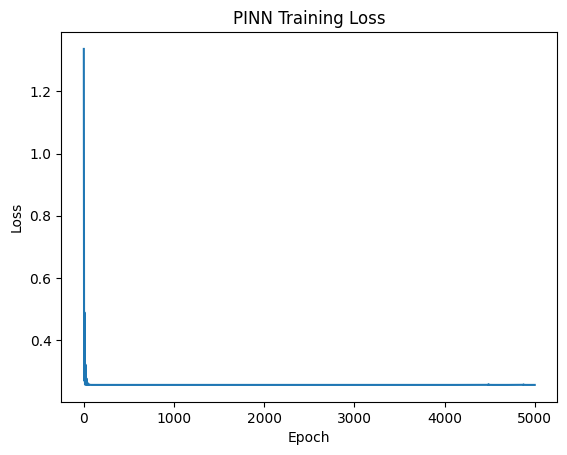

In [ ]:
#8. Plot Training Loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.show()

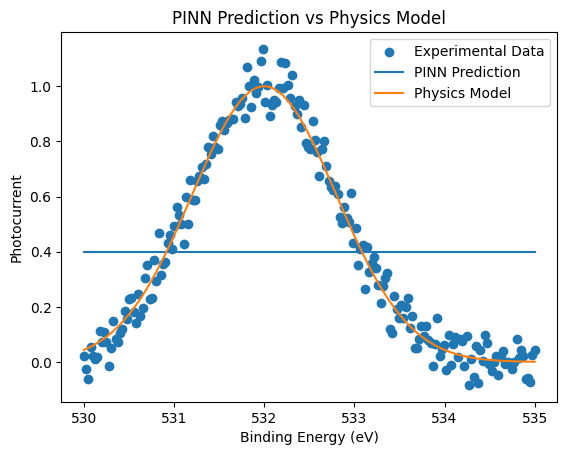

In [ ]:
#9. Evaluate the Model

pred = model(Eb_t).detach().numpy()

plt.figure()

plt.scatter(Eb,I_exp,label="Experimental Data")

plt.plot(Eb,pred,label="PINN Prediction")

plt.plot(Eb,I_ph,label="Physics Model")

plt.legend()

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Photocurrent")

plt.title("PINN Prediction vs Physics Model")

plt.show()

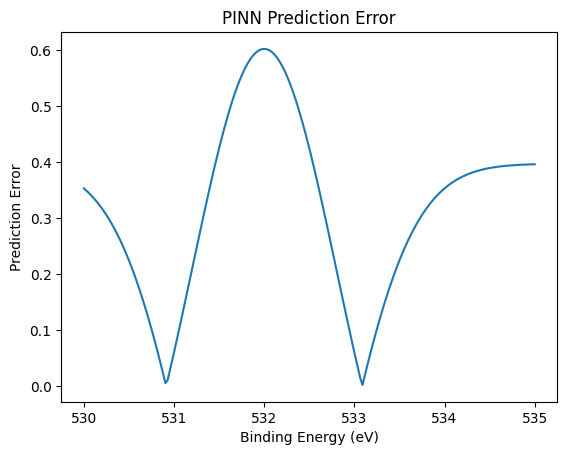

In [ ]:
#error analysis

error = np.abs(pred.flatten()-I_ph)

plt.figure()
plt.plot(Eb,error)
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Prediction Error")
plt.title("PINN Prediction Error")
plt.show()